In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from matplotlib import pyplot as plt
from scipy import stats
import warnings
import duckdb
import statsmodels.api as sm

### Original Data T-Test for Accuracy

In [ ]:
original = pd.read_excel('demo_analysis.xlsx')

c:\Users\nikhi\anaconda3\envs\data\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Web Extension extension is not supported and will be removed
  warn(msg)


In [ ]:
rel1 = stats.ttest_rel(a=original['prHit1Make'], b=original['prHit1Miss'], alternative='two-sided')
print(f"k=1: T={rel1.statistic:.2f}, p={rel1.pvalue:.2f}")
rel2 = stats.ttest_rel(a=original['prHit2Makes'], b=original['prHit2Misses'], alternative='two-sided')
print(f"k=2: T={rel2.statistic:.2f}, p={rel2.pvalue:.2f}")
rel3 = stats.ttest_rel(a=original['prHit3Makes'], b=original['prHit3Misses'], alternative='two-sided')
print(f"k=3: T={rel3.statistic:.2f}, p={rel3.pvalue:.2f}")

k=1: T=-2.73, p=0.03
k=2: T=-3.11, p=0.01
k=3: T=-4.42, p=0.00


### Cornell Data T-Test (unadjusted)

In [ ]:
cornell = pd.read_excel('analysis.xlsx')
cornell_filtered = cornell[cornell['countHit'] >= 100]

rel1 = stats.ttest_rel(a=cornell_filtered['prHit1Make'], b=table['prHit1Miss'], alternative='two-sided')
print(f"k=1: T={rel1.statistic:.2f}, p={rel1.pvalue:.2f}")
rel2 = stats.ttest_rel(a=cornell_filtered['prHit2Makes'], b=cornell_filtered['prHit2Misses'], alternative='two-sided')
print(f"k=2: T={rel2.statistic:.2f}, p={rel2.pvalue:.2f}")
rel3 = stats.ttest_rel(a=cornell_filtered['prHit3Makes'], b=cornell_filtered['prHit3Misses'], alternative='two-sided')
print(f"k=3: T={rel3.statistic:.2f}, p={rel3.pvalue:.2f}")

k=1: T=-1.10, p=0.30
k=2: T=-1.78, p=0.11
k=3: T=-0.62, p=0.55


### Bias Values Simulation

In [ ]:
def get_exp_prop(n, k, p, nsims):
    data = np.random.binomial(1, p, size=(nsims,n))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning) #ignore na means that happen below

        if k == 1:
            y = [np.array([data[i,j] for j in range(n-1) if data[i,j-1] == 1]).mean() for i in range(nsims)] #calculate the lagged mean for each simulation
        if k == 2:
            y = [np.array([data[i,j] for j in range(n-2) if data[i,j-1] == 1 & data[i,j-2] == 1]).mean() for i in range(nsims)]
        if k == 3:
            y = [np.array([data[i,j] for j in range(n-3) if data[i,j-1] == 1 & data[i,j-2] == 1 & data[i,j-3] == 1]).mean() for i in range(nsims)]

        y = np.array(y)[~np.isnan(y)] #remove na samples
        return y.mean()

In [ ]:
expected_props = np.zeros(shape=(101, 3, 3))
for n in tqdm(range(101)):
    for index_k, k in enumerate(range(1,4)):
        for index_p, p in enumerate([0.25,0.5,0.75]):
            expected_props[n, index_k, index_p] = get_exp_prop(n, k, p, 1000)

100%|██████████| 101/101 [00:21<00:00,  4.71it/s]


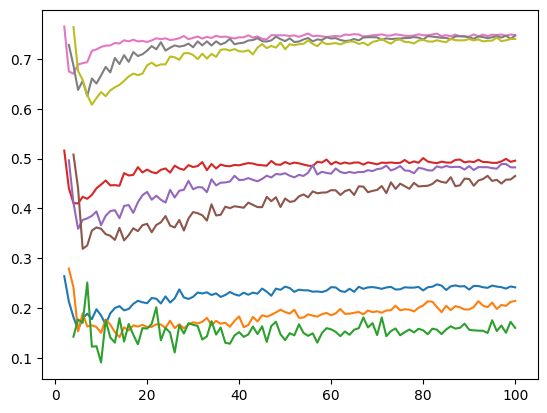

In [ ]:
plt.plot(expected_props[:,0,0])
plt.plot(expected_props[:,1,0])
plt.plot(expected_props[:,2,0])

plt.plot(expected_props[:,0,1])
plt.plot(expected_props[:,1,1])
plt.plot(expected_props[:,2,1])

plt.plot(expected_props[:,0,2])
plt.plot(expected_props[:,1,2])
plt.plot(expected_props[:,2,2])

### Bias Values Exact Calculation

See Appendix E of paper for explanation.

In [ ]:
def increment_count(D:dict, l,r, m_prime, p_prime):
    return {tuple(map(sum, zip(k, m_prime))): D[(l,r)][k] * p_prime for k in D[(l,r)].keys()}

def union_sum(A:dict, B:dict):
    return {k: A.get(k, 0) + B.get(k, 0) for k in A.keys() | B.keys()}

In [ ]:
def count_distribution(N, k, p):
    D = dict()
    q = 1-p
    for n in range(N):
        L = min(k,n)
        for l in range(L,-1,-1):
            r = n - l
            if r == 0:
                D[(l,r)] = {(0,0):1.0}
            elif r > 0:
                if l < k:
                    D[(l,r)] = union_sum(increment_count(D, 0,r-1, (0,0), q),increment_count(D, l+1,r-1, (0,0), p))
                elif l == k:
                    D[(l,r)] = union_sum(increment_count(D, 0,r-1, (1,0), q),increment_count(D, k,r-1, (0,1), p))

    return D

For each `count_distribution` output, the outer key (`i,j`) represents the probability distribution of counts for `i` successes before current trial and `j` trials remaining. So, all of the `0,j` values are important, while others don't matter. Computation is needed for 3 values of `k` and 3 values of `p` but `N` is fixed at `101`. See Appendix E (p. 43) for probability distribution to expected value details. 

In [ ]:
def get_exp_prop(dist: dict, n):
    dist[(0,n)].pop((0,0)) #remove 0,0 from calculations
    return sum([dist[(0,n)][(i,j)]/sum(dist[(0,n)].values()) * (j/(i+j)) for (i,j) in dist[(0,n)].keys()]) #appendix e calculation

In [ ]:
expected_props = np.zeros(shape=(100, 3, 3))
for index_k, k in tqdm(enumerate(range(1,4))):
    for index_p, p in enumerate([0.25,0.5,0.75]):
        dist = count_distribution(101, k, p)
        for n in range(1,101):
            expected_props[n-1, index_k, index_p] = get_exp_prop(dist, n)

3it [00:07,  2.36s/it]


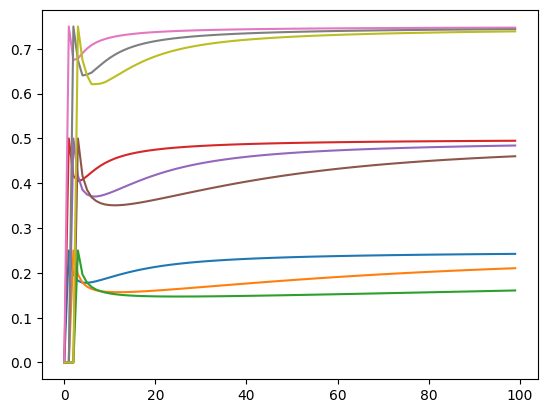

In [ ]:
plt.plot(expected_props[:,0,0])
plt.plot(expected_props[:,1,0])
plt.plot(expected_props[:,2,0])

plt.plot(expected_props[:,0,1])
plt.plot(expected_props[:,1,1])
plt.plot(expected_props[:,2,1])

plt.plot(expected_props[:,0,2])
plt.plot(expected_props[:,1,2])
plt.plot(expected_props[:,2,2])

### Adjusted Bias For Cornell

In [ ]:
cornell_corrected = cornell_filtered.iloc[:,:-3]
cornell_corrected.head()

,athleteId,name,position,year,count3Misses,prHit3Misses,count2Misses,prHit2Misses,count1Miss,prHit1Miss,countHit,prHit,count1Make,prHit1Make,count2Makes,prHit2Makes,count3Makes,prHit3Makes
0,5106247,Cooper Noard,G,SR,16,0.562500,47,0.617021,119,0.571429,279,0.519713,137,0.452555,56,0.464286,24,0.375000
1,5106243,Adam Hinton,G,SR,15,0.666667,39,0.564103,98,0.561224,218,0.490826,97,0.432990,34,0.470588,12,0.583333
2,5175900,Jake Fiegen,G,SR,17,0.588235,36,0.444444,86,0.534884,210,0.542857,105,0.561905,53,0.528302,27,0.518519
3,5175898,Jacob Beccles,G,JR,10,0.400000,22,0.318182,54,0.388889,131,0.465649,54,0.537037,26,0.423077,10,0.300000
4,5106245,Josh Baldwin,G,SR,10,0.500000,24,0.416667,57,0.456140,119,0.428571,42,0.404762,13,0.307692,4,0.250000


In [ ]:
#Takes ~5 mins to run
for index, row in tqdm(cornell_corrected.iterrows()):
    #below calculates the adjusted probability - how much bias there is and subtracting that from the observed value
    cornell_corrected.loc[index, 'prHit3Misses'] = row['prHit3Misses'] - (1-row['prHit'] - get_exp_prop(count_distribution(1+int(row['countHit']), 3, 1-row['prHit']), row['countHit']))
    cornell_corrected.loc[index, 'prHit3Makes'] = row['prHit3Makes'] + (row['prHit'] - get_exp_prop(count_distribution(1+int(row['countHit']), 3, row['prHit']), row['countHit']))
    
    cornell_corrected.loc[index, 'prHit2Misses'] = row['prHit2Misses'] - (1-row['prHit'] - get_exp_prop(count_distribution(1+int(row['countHit']), 2, 1-row['prHit']), row['countHit']))
    cornell_corrected.loc[index, 'prHit2Makes'] = row['prHit2Makes'] + (row['prHit'] - get_exp_prop(count_distribution(1+int(row['countHit']), 2, row['prHit']), row['countHit']))
    
    cornell_corrected.loc[index, 'prHit1Miss'] = row['prHit1Miss'] - (1-row['prHit'] - get_exp_prop(count_distribution(1+int(row['countHit']), 1, 1-row['prHit']), row['countHit']))
    cornell_corrected.loc[index, 'prHit1Make'] = row['prHit1Make'] + (row['prHit'] - get_exp_prop(count_distribution(1+int(row['countHit']), 1, row['prHit']), row['countHit']))

10it [05:33, 33.37s/it]


Below is a sample calculation based on the first row of Table 2 of Miller

In [ ]:
.5 + (0.54 - get_exp_prop(count_distribution(101, 3, 0.54), 100)) - (.44 - (1-0.54 - get_exp_prop(count_distribution(101, 3, 1-0.54), 100)))

0.1411484667532784

### T-Test for Cornell (adjusted)

In [ ]:
rel1 = stats.ttest_rel(a=cornell_corrected['prHit1Make'], b=cornell_corrected['prHit1Miss'], alternative='two-sided')
print(f"k=1: T={rel1.statistic:.2f}, p={rel1.pvalue:.2f}")
rel2 = stats.ttest_rel(a=cornell_corrected['prHit2Makes'], b=cornell_corrected['prHit2Misses'], alternative='two-sided')
print(f"k=2: T={rel2.statistic:.2f}, p={rel2.pvalue:.2f}")
rel3 = stats.ttest_rel(a=cornell_corrected['prHit3Makes'], b=cornell_corrected['prHit3Misses'], alternative='two-sided')
print(f"k=3: T={rel3.statistic:.2f}, p={rel3.pvalue:.2f}")

k=1: T=-0.89, p=0.40
k=2: T=-1.19, p=0.26
k=3: T=-0.08, p=0.94


### Distance Calculation

In [63]:
shots = pd.read_csv('../scraper/mens/shots.csv')
shots = pd.concat([shots, pd.read_csv('../scraper/womens/shots.csv')], axis=0)
shots['scoringPlay'] = shots['scoringPlay'].notna() #make scoring T/F
shots = shots.rename(columns={'athlete.id':'athleteId'})
players = pd.read_csv('../scraper/mens/players.csv')
players = pd.concat([players,pd.read_csv('../scraper/womens/players.csv')], axis=0)

shots = shots[shots['athleteId'].isin(players['id'])].reset_index(drop=True) #get Cornell players only
non_ft_shots = shots[shots['type.txt'] != 'MadeFreeThrow'] # made free throw includes misses, can use != 1001 or 1004 for typeID too

### Distance Regression (Fixed Effects)

In [81]:
shots_conditional = duckdb.sql("""SELECT *, 
                  LAG(scoringPlay, 1, NULL) OVER(PARTITION BY athleteId, gameId ORDER BY id) AS prevShot,
                  LAG(scoringPlay, 2, NULL) OVER(PARTITION BY athleteId, gameId ORDER BY id) AS prev2Shot,
                  LAG(scoringPlay, 3, NULL) OVER(PARTITION BY athleteId, gameId ORDER BY id) AS prev3Shot,
                  FROM non_ft_shots
                  ORDER BY athleteId, id""").df()

shots_conditional['distance'] = np.sqrt((shots_conditional['coordinate.x']-25)**2 + (shots_conditional['coordinate.y']-0)**2)
shots_conditional = shots_conditional.dropna()
shots_conditional['madeLast3'] = shots_conditional['prevShot'] & shots_conditional['prev2Shot'] & shots_conditional['prev3Shot']
shots_conditional['madeLast2'] = shots_conditional['prevShot'] & shots_conditional['prev2Shot']
shots_conditional['madeLast1'] = shots_conditional['prevShot']

In [82]:
dummies = pd.get_dummies(shots_conditional['athleteId'], drop_first=True)
shots_conditional = pd.concat([shots_conditional,dummies],axis=1)
cols = [*['distance','madeLast1','madeLast2','madeLast3'],*dummies.columns]

model = sm.Logit(shots_conditional['scoringPlay'],sm.add_constant(shots_conditional[cols].astype(int))).fit_regularized()
print(model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.6488069954966132
            Iterations: 259
            Function evaluations: 261
            Gradient evaluations: 259
                           Logit Regression Results                           
Dep. Variable:            scoringPlay   No. Observations:                 1742
Model:                          Logit   Df Residuals:                     1708
Method:                           MLE   Df Model:                           33
Date:                Sat, 21 Mar 2026   Pseudo R-squ.:                 0.05779
Time:                        21:26:11   Log-Likelihood:                -1130.2
converged:                       True   LL-Null:                       -1199.5
Covariance Type:            nonrobust   LLR p-value:                 6.619e-15
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

### Distances T-Tests

In [83]:
dist_3miss = duckdb.sql("""SELECT athleteId, COUNT() as count3Misses, AVG(distance) as distance3Misses
                         FROM shots_conditional
                         WHERE prevShot = False AND prev2Shot = False AND prev3Shot = False
                         GROUP BY athleteId""").df()

dist_2miss = duckdb.sql("""SELECT athleteId, COUNT() as count2Misses, AVG(distance) as distance2Misses
                         FROM shots_conditional
                         WHERE prevShot = False AND prev2Shot = False
                         GROUP BY athleteId""").df()

dist_miss = duckdb.sql("""SELECT athleteId, COUNT() as count1Miss, AVG(distance) as distance1Miss
                         FROM shots_conditional
                         WHERE prevShot = False
                         GROUP BY athleteId""").df()

dist_3makes = duckdb.sql("""SELECT athleteId, COUNT() as count3Makes, AVG(distance) as distance3Makes
                         FROM shots_conditional
                         WHERE prevShot = True AND prev2Shot = True AND prev3Shot = True
                         GROUP BY athleteId""").df()

dist_2makes = duckdb.sql("""SELECT athleteId, COUNT() as count2Makes, AVG(distance) as distance2Makes
                         FROM shots_conditional
                         WHERE prevShot = True AND prev2Shot = True
                         GROUP BY athleteId""").df()

dist_make = duckdb.sql("""SELECT athleteId, COUNT() as count1Make, AVG(distance) as distance1Make
                         FROM shots_conditional
                         WHERE prevShot = True
                         GROUP BY athleteId""").df()

dist = duckdb.sql("""SELECT athleteId, COUNT() as count, AVG(distance) as distance
                         FROM shots_conditional
                         GROUP BY athleteId""").df()

In [84]:
table = duckdb.sql("""SELECT * FROM
                    dist
                    LEFT JOIN dist_3miss ON dist.athleteId = dist_3miss.athleteId
                    LEFT JOIN dist_2miss ON dist.athleteId = dist_2miss.athleteId
                    LEFT JOIN dist_miss ON dist.athleteId = dist_miss.athleteId
                    LEFT JOIN dist_make ON dist.athleteId = dist_make.athleteId
                    LEFT JOIN dist_2makes ON dist.athleteId = dist_2makes.athleteId
                    LEFT JOIN dist_3makes ON dist.athleteId = dist_3makes.athleteId""").df()

table = table.loc[:,~table.columns.str.startswith('athleteId_')] #removes duplicate athleteId columns
table.to_csv('distances.csv')

In [85]:
table = table.dropna()
rel1 = stats.ttest_rel(a=table['distance1Make'], b=table['distance1Miss'], alternative='greater')
print(f"k=1: T={rel1.statistic:.2f}, p={rel1.pvalue:.2f}")
rel2 = stats.ttest_rel(a=table['distance2Makes'], b=table['distance2Misses'], alternative='greater')
print(f"k=2: T={rel2.statistic:.2f}, p={rel2.pvalue:.2f}")
rel3 = stats.ttest_rel(a=table['distance3Makes'], b=table['distance3Misses'], alternative='greater')
print(f"k=3: T={rel3.statistic:.2f}, p={rel3.pvalue:.2f}")

k=1: T=2.66, p=0.01
k=2: T=2.49, p=0.01
k=3: T=1.54, p=0.07
